🔍 Found 6 high-prominence peaks.


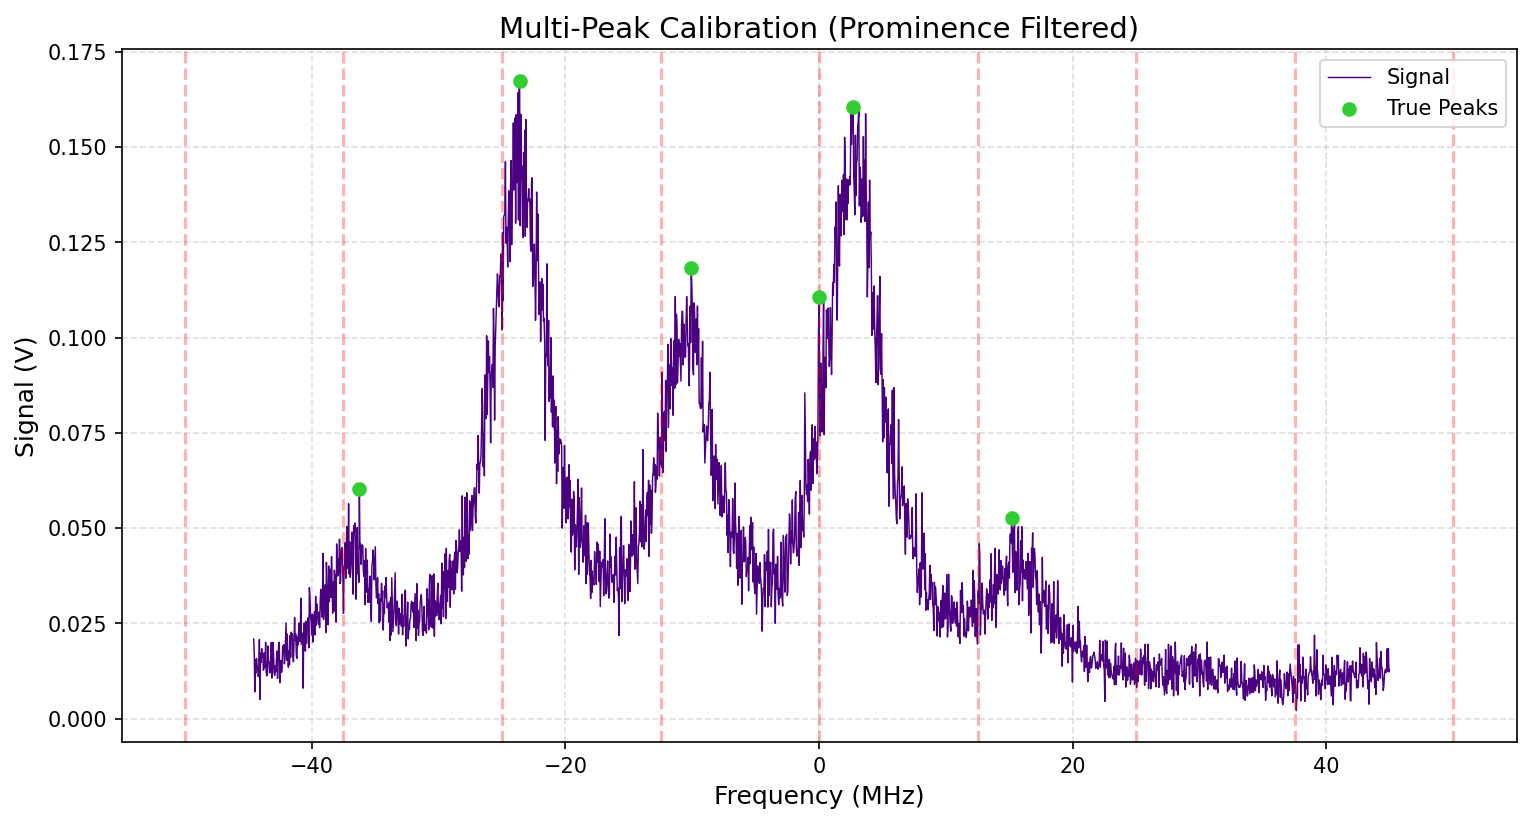

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import find_peaks
from pathlib import Path

# --- LOAD DATA ---
data_dir = Path("/Users/michelangelodondi/Documents/Research/rb6s-spectroscopy/data/01_raw/power_eom")
f = data_dir / "4121nm_eom_after1.csv"
df = pd.read_csv(f, skiprows=2, header=None)
df.columns = ['time_s', 'signal_v']
df = df.apply(pd.to_numeric, errors='coerce').dropna()

# --- UPGRADED PEAK DETECTION ---
# Prominence filters out the "fuzz" by requiring a peak to rise out of its local valley
# Adjust prominence up (e.g., 0.005) if it still catches noise, or down (0.001) if it misses a sideband
peaks, props = find_peaks(df['signal_v'], prominence=0.03, distance=150)

t_peaks = df['time_s'].iloc[peaks].values
v_peaks = df['signal_v'].iloc[peaks].values

# Sort peaks by time
sort_idx = np.argsort(t_peaks)
t_peaks = t_peaks[sort_idx]
v_peaks = v_peaks[sort_idx]

print(f"🔍 Found {len(t_peaks)} high-prominence peaks.")

# --- CALIBRATION LOGIC ---
if len(t_peaks) >= 3:
    spacings = np.diff(t_peaks)
    avg_spacing = np.median(spacings)
    mhz_per_s = 12.5 / avg_spacing
    
    # Identify the Center (0 MHz)
    center_idx = len(t_peaks) // 2
    t_zero = t_peaks[center_idx]
    
    df['freq_mhz'] = (df['time_s'] - t_zero) * mhz_per_s
    
    # --- PLOTTING ---
    plt.figure(figsize=(12, 6), dpi=150)
    plt.plot(df['freq_mhz'], df['signal_v'], color='indigo', linewidth=0.7, label='Signal')
    
    # Mark EVERY detected peak with a green dot
    plt.scatter((t_peaks - t_zero) * mhz_per_s, v_peaks, color='limegreen', zorder=5, label='True Peaks')

    # Draw the 12.5 MHz theoretical grid
    for i in range(-4, 5):
        plt.axvline(i * 12.5, color='red', linestyle='--', alpha=0.3)

    plt.title(f"Multi-Peak Calibration (Prominence Filtered)", fontsize=14)
    plt.xlabel("Frequency (MHz)", fontsize=12)
    plt.ylabel("Signal (V)", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.legend()
    plt.show()
else:
    print("❌ Not enough peaks found. Lower 'prominence' slightly.")